# Sistema de Recomendação com Filtragem Colaborativa (Collaborative Filtering)

**Aplicações de Negócio de Redes Neurais — FGV MBA em Inteligência Artificial**

## Contexto de negócio

Imagine uma plataforma de streaming (filmes/séries) ou um e-commerce que precisa decidir **quais itens recomendar** para cada usuário. O problema central é: *como prever a nota (rating) que um usuário daria a um item que ele ainda não avaliou?*

Se conseguirmos estimar essa nota com boa precisão para todos os pares usuário-item não observados, basta ordenar os itens pela nota prevista e recomendar os melhores. Esse é o princípio por trás de sistemas como Netflix, Spotify e Amazon.

Neste notebook vamos:
1. Simular um conjunto de usuários e itens com "gostos" e "características" ocultos (latentes);
2. Gerar avaliações observadas parciais (cada usuário só avalia parte do catálogo);
3. Construir um **baseline simples** (sem aprendizado latente);
4. Construir um **modelo de rede neural de filtragem colaborativa** (embeddings de usuário e item);
5. Comparar os dois pelo erro de previsão (RMSE) em avaliações nunca vistas pelo modelo.


**1. Por que uma rede neural ajuda neste problema?**

O desafio de recomendação é essencialmente encontrar **padrões latentes**: usuários com gostos parecidos tendem a gostar de itens parecidos, mas esses "gostos" não estão em nenhuma coluna do banco de dados — eles são implícitos nos padrões de avaliação.

Uma rede neural com camadas de **Embedding** aprende, para cada usuário e cada item, um vetor numérico (representação latente) diretamente a partir dos dados de avaliação, sem que ninguém precise definir manualmente essas dimensões. Isso permite capturar interações não-lineares entre gosto do usuário e característica do item — algo que uma média simples (baseline) não consegue capturar, pois ela ignora completamente a personalização por usuário.


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)

pd.set_option('display.precision', 3)
print('Bibliotecas carregadas. TensorFlow versão:', tf.__version__)


Bibliotecas carregadas. TensorFlow versão: 2.21.0


**2. Geração do dataset simulado**

Vamos criar:
- 40 usuários, cada um com um vetor de "gosto" oculto em 3 dimensões latentes;
- 25 itens, cada um com um vetor de "característica" oculta nas mesmas 3 dimensões;
- um viés (bias) de usuário e um viés de item, simulando usuários mais rigorosos/generosos e itens mais bem/mal avaliados em média;
- o rating "verdadeiro" de um par (usuário, item) é o produto escalar entre os vetores latentes, mais os vieses, mapeado para uma escala de 1 a 5, com ruído gaussiano.


In [2]:
N_USUARIOS = 40
N_ITENS = 25
DIM_LATENTE = 3

# Vetores de gosto (usuários) e característica (itens) ocultos
gosto_usuario = np.random.normal(0, 1, size=(N_USUARIOS, DIM_LATENTE))
caracteristica_item = np.random.normal(0, 1, size=(N_ITENS, DIM_LATENTE))

# Vieses individuais (usuário mais exigente/generoso; item mais popular/impopular)
vies_usuario = np.random.normal(0, 0.4, size=N_USUARIOS)
vies_item = np.random.normal(0, 0.4, size=N_ITENS)

# Nota "crua" = produto escalar + vieses + média global
media_global = 3.2
rating_bruto = (gosto_usuario @ caracteristica_item.T) + vies_usuario[:, None] + vies_item[None, :] + media_global

print('Forma da matriz de rating bruto (usuarios x itens):', rating_bruto.shape)
print('Estatísticas do rating bruto (antes de recortar 1-5 e adicionar ruído):')
print(pd.Series(rating_bruto.flatten()).describe())


Forma da matriz de rating bruto (usuarios x itens): (40, 25)
Estatísticas do rating bruto (antes de recortar 1-5 e adicionar ruído):
count    1000.000
mean        3.264
std         1.635
min        -4.967
25%         2.398
50%         3.359
75%         4.309
max         9.256
dtype: float64


**3. Montagem das avaliações observadas**

Na vida real, cada usuário avalia apenas uma fração do catálogo. Vamos sortear, para cada usuário, entre 40% e 60% dos itens como "avaliados", adicionar ruído gaussiano ao rating verdadeiro e recortar o resultado para a escala de 1 a 5. O restante dos pares fica sem avaliação — é justamente o que um sistema de recomendação real precisaria prever.


In [3]:
registros = []

for u in range(N_USUARIOS):
    frac_avaliada = np.random.uniform(0.4, 0.6)
    n_avaliar = max(1, int(round(frac_avaliada * N_ITENS)))
    itens_avaliados = np.random.choice(N_ITENS, size=n_avaliar, replace=False)

    for i in itens_avaliados:
        ruido = np.random.normal(0, 0.5)
        rating = rating_bruto[u, i] + ruido
        rating = np.clip(rating, 1.0, 5.0)
        registros.append((u, i, rating))

df = pd.DataFrame(registros, columns=['usuario_id', 'item_id', 'rating'])

print(f'Total de avaliações observadas: {len(df)} de {N_USUARIOS * N_ITENS} pares possíveis '
      f'({100 * len(df) / (N_USUARIOS * N_ITENS):.1f}% de densidade)')
df.head(10)


Total de avaliações observadas: 491 de 1000 pares possíveis (49.1% de densidade)


,usuario_id,item_id,rating
0,0,5,2.758
1,0,22,3.408
2,0,11,2.469
3,0,10,3.912
4,0,24,4.398
5,0,14,4.865
6,0,8,3.140
7,0,17,3.975
8,0,7,4.304
9,0,23,3.499


**4. Separação treino/teste**

Vamos separar as triplas (usuario_id, item_id, rating) observadas em 80% treino e 20% teste. O modelo será avaliado em pares usuário-item que ele nunca viu durante o treinamento — simulando exatamente a tarefa real de prever avaliações futuras.


In [4]:
treino_df, teste_df = train_test_split(df, test_size=0.2, random_state=42)

print('Tamanho treino:', len(treino_df))
print('Tamanho teste:', len(teste_df))

X_treino_usuario = treino_df['usuario_id'].values
X_treino_item = treino_df['item_id'].values
y_treino = treino_df['rating'].values

X_teste_usuario = teste_df['usuario_id'].values
X_teste_item = teste_df['item_id'].values
y_teste = teste_df['rating'].values


Tamanho treino: 392
Tamanho teste: 99


**5. Baseline: média do item (popularidade)**

Um baseline simples e comum em recomendação é prever, para qualquer usuário, a **média histórica de rating do item** (ignorando quem é o usuário). Isso captura "popularidade" do item, mas não personaliza nada por usuário — é exatamente o tipo de padrão que a rede neural deve superar ao aprender os vetores latentes de gosto/característica.

Para itens sem nenhuma avaliação no treino, usamos a média global de treino como valor de reserva (fallback).


In [5]:
media_global_treino = treino_df['rating'].mean()
media_por_item = treino_df.groupby('item_id')['rating'].mean()

def prever_baseline(item_ids):
    return np.array([
        media_por_item.get(i, media_global_treino) for i in item_ids
    ])

pred_baseline_teste = prever_baseline(X_teste_item)

rmse_baseline = np.sqrt(np.mean((pred_baseline_teste - y_teste) ** 2))
print(f'Média global (treino): {media_global_treino:.3f}')
print(f'RMSE do baseline (média do item) no conjunto de teste: {rmse_baseline:.4f}')


Média global (treino): 3.334
RMSE do baseline (média do item) no conjunto de teste: 1.4182


**6. Modelo de rede neural: filtragem colaborativa com embeddings**

Agora construímos uma rede neural que aprende, para cada usuário e cada item, um vetor de embedding (representação latente aprendida, com 4 dimensões), além de um viés (bias) treinável por usuário e por item. A previsão é o produto escalar entre os dois embeddings, somado aos vieses — uma arquitetura conhecida como *fatoração de matrizes neural* (neural matrix factorization).

Essa arquitetura casa diretamente com o processo que gerou os dados simulados (produto escalar de vetores latentes + vieses), e é uma escolha clássica e eficiente para bases de avaliação esparsas, mesmo quando pequenas.

Diferente do baseline, esse modelo **personaliza** a previsão por usuário, pois seus embeddings e vieses são treináveis e específicos para cada usuario_id.


In [6]:
DIM_EMBEDDING = 4
REG_L2 = keras.regularizers.l2(1e-4)

entrada_usuario = layers.Input(shape=(1,), name='usuario_id')
entrada_item = layers.Input(shape=(1,), name='item_id')

emb_usuario = layers.Embedding(
    input_dim=N_USUARIOS, output_dim=DIM_EMBEDDING,
    embeddings_regularizer=REG_L2, name='embedding_usuario'
)(entrada_usuario)
emb_item = layers.Embedding(
    input_dim=N_ITENS, output_dim=DIM_EMBEDDING,
    embeddings_regularizer=REG_L2, name='embedding_item'
)(entrada_item)

vies_usuario_emb = layers.Embedding(input_dim=N_USUARIOS, output_dim=1, name='vies_usuario')(entrada_usuario)
vies_item_emb = layers.Embedding(input_dim=N_ITENS, output_dim=1, name='vies_item')(entrada_item)

vetor_usuario = layers.Flatten()(emb_usuario)
vetor_item = layers.Flatten()(emb_item)

produto_escalar = layers.Dot(axes=1, name='produto_escalar')([vetor_usuario, vetor_item])
vies_usuario_flat = layers.Flatten()(vies_usuario_emb)
vies_item_flat = layers.Flatten()(vies_item_emb)

soma = layers.Add(name='soma_produto_e_vieses')([produto_escalar, vies_usuario_flat, vies_item_flat])
saida = layers.Dense(1, activation='linear', name='rating_previsto')(soma)

modelo = keras.Model(inputs=[entrada_usuario, entrada_item], outputs=saida)
modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=0.02), loss='mse')

modelo.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ usuario_id          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_id             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_usuario   │ (None, 1, 4)      │        160 │ usuario_id[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_item      │ (None, 1, 4)      │        100 │ item_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ embedding_usuari… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4)         │          0 │ embedding_item[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vies_usuario        │ (None, 1, 1)      │         40 │ usuario_id[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vies_item           │ (None, 1, 1)      │         25 │ item_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ produto_escalar     │ (None, 1)         │          0 │ flatten[0][0],    │
│ (Dot)               │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 1)         │          0 │ vies_usuario[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 1)         │          0 │ vies_item[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ soma_produto_e_vie… │ (None, 1)         │          0 │ produto_escalar[… │
│ (Add)               │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating_previsto     │ (None, 1)         │          2 │ soma_produto_e_v… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 327 (1.28 KB)

 Trainable params: 327 (1.28 KB)

 Non-trainable params: 0 (0.00 B)

**7. Treinamento do modelo**

Treinamos por um número moderado de épocas (dataset pequeno e simulado), usando MSE como função de perda — a mesma métrica de base do RMSE que usaremos para comparação. Usamos parada antecipada (*early stopping*) monitorando a perda de validação, para evitar overfitting em um dataset tão pequeno.


In [7]:
parada_antecipada = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

historico = modelo.fit(
    [X_treino_usuario, X_treino_item],
    y_treino,
    validation_split=0.15,
    epochs=200,
    batch_size=16,
    callbacks=[parada_antecipada],
    verbose=0
)

n_epocas_rodadas = len(historico.history['loss'])
melhor_epoca = int(np.argmin(historico.history['val_loss']))
print(f'Treinamento concluído em {n_epocas_rodadas} épocas (parada antecipada).')
print(f'Melhor época (pesos restaurados): {melhor_epoca + 1}')
print(f"Perda (treino) na melhor época: {historico.history['loss'][melhor_epoca]:.4f}")
print(f"Perda (validação) na melhor época: {historico.history['val_loss'][melhor_epoca]:.4f}")


Treinamento concluído em 20 épocas (parada antecipada).
Melhor época (pesos restaurados): 5
Perda (treino) na melhor época: 0.8034
Perda (validação) na melhor época: 1.3650


**8. Avaliação do modelo neural no conjunto de teste**


In [8]:
pred_modelo_teste = modelo.predict([X_teste_usuario, X_teste_item], verbose=0).flatten()

rmse_modelo = np.sqrt(np.mean((pred_modelo_teste - y_teste) ** 2))
print(f'RMSE do modelo neural (collaborative filtering) no conjunto de teste: {rmse_modelo:.4f}')


RMSE do modelo neural (collaborative filtering) no conjunto de teste: 1.2612


**9. Comparação lado a lado: baseline vs. rede neural**


In [9]:
comparacao = pd.DataFrame({
    'Abordagem': ['Baseline (média do item)', 'Rede neural (collaborative filtering)'],
    'RMSE (teste)': [rmse_baseline, rmse_modelo]
})
comparacao['Melhora vs. baseline (%)'] = [
    0.0,
    100 * (rmse_baseline - rmse_modelo) / rmse_baseline
]
comparacao


,Abordagem,RMSE (teste),Melhora vs. baseline (%)
0,Baseline (média do item),1.418,0.000
1,Rede neural (collaborative filtering),1.261,11.071


**10. Gráfico: curva de aprendizado e dispersão de previsões**


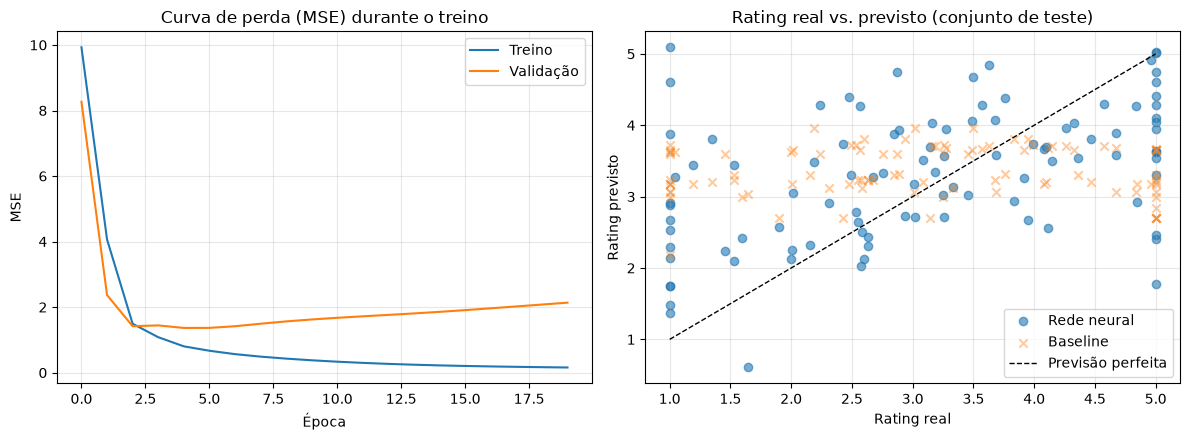

In [10]:
import matplotlib.pyplot as plt

fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5))

# Curva de perda ao longo do treino
eixos[0].plot(historico.history['loss'], label='Treino')
eixos[0].plot(historico.history['val_loss'], label='Validação')
eixos[0].set_title('Curva de perda (MSE) durante o treino')
eixos[0].set_xlabel('Época')
eixos[0].set_ylabel('MSE')
eixos[0].legend()
eixos[0].grid(alpha=0.3)

# Dispersão: rating real vs previsto (modelo neural) no teste
eixos[1].scatter(y_teste, pred_modelo_teste, alpha=0.6, label='Rede neural')
eixos[1].scatter(y_teste, pred_baseline_teste, alpha=0.4, marker='x', label='Baseline')
eixos[1].plot([1, 5], [1, 5], 'k--', linewidth=1, label='Previsão perfeita')
eixos[1].set_title('Rating real vs. previsto (conjunto de teste)')
eixos[1].set_xlabel('Rating real')
eixos[1].set_ylabel('Rating previsto')
eixos[1].legend()
eixos[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**11. Conclusão qualitativa**

Neste exemplo simulado, o baseline de "média do item" já é razoável porque captura popularidade geral, mas ignora completamente o gosto individual de cada usuário. O modelo de rede neural com embeddings aprende uma representação latente por usuário e por item — reproduzindo o mecanismo que efetivamente gerou os dados (produto escalar de vetores latentes) — e por isso consegue personalizar a previsão.

Pontos importantes para levar para a prática de negócio:

- **Dado esparso é a norma**: em sistemas reais, a densidade de avaliações é tipicamente muito menor que os 40-60% simulados aqui, o que torna o aprendizado de embeddings mais difícil e exige mais dados ou técnicas de regularização.
- **Cold start**: usuários ou itens novos, sem histórico de avaliação, não têm embedding bem treinado — esse é um problema clássico de sistemas de recomendação que redes neurais puras não resolvem sozinhas (é comum combinar com conteúdo/metadados).
- **Baseline não é descartável**: em produção, é comum usar o baseline como fallback para casos de cold start e o modelo neural para os demais casos.
- Os números absolutos de RMSE mostrados acima refletem apenas este dataset simulado com ruído controlado; em dados reais a diferença de desempenho entre baseline e modelo pode variar bastante conforme volume de dados e esparsidade.
